# Urban Demand Forecasting — RQ6 


This standalone notebook implements **RQ6** from the thesis proposal:

**How can explainable AI methods reveal the relative and context-dependent importance of weather, calendar, and neighborhood factors in forecasting shared mobility demand?**

The notebook is Kaggle-ready and auto-fetches the UCI Bike Sharing Dataset if `hour.csv` is not already available. Turn **Internet = On** in Kaggle Notebook Settings.

## Thesis-ready outputs

The notebook saves thesis-ready outputs to `/kaggle/working/urban_demand_RQ6_outputs/`:

- 4 PDF figures with readable titles, labels, notes, and values
- 5 CSV tables including interpretation columns
- 1 final ZIP containing all outputs

## Important dataset note

The UCI Bike Sharing dataset includes real hourly demand, weather, and calendar variables, but it does **not** include real station-level POI, land-use, or neighborhood metadata. Therefore, the notebook uses transparent **proxy neighborhood-context features** so the RQ6 pipeline can run end-to-end. In the thesis, describe neighborhood explanations as proxy-based spatial-context evidence, not definitive real-world POI attribution.


In [1]:
RQ = 'RQ6'

# ============================================================
# Common setup: auto-fetch dataset, preprocessing, metrics, models
# ============================================================
import os, glob, zipfile, urllib.request, warnings, shutil, math, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RQ = globals().get('RQ', 'RQ')
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_DIR / f'urban_demand_{RQ}_outputs'
FIG_DIR = OUTPUT_DIR / 'figures_pdf'
TAB_DIR = OUTPUT_DIR / 'tables_csv'
for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)

def section(title):
    print('\n' + '='*90)
    print(title)
    print('='*90)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path

def save_fig(name):
    path = FIG_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path

def find_or_download_hour_csv():
    candidates = []
    search_roots = ['/kaggle/input', '/kaggle/working', str(Path.cwd()), '/mnt/data']
    for root in search_roots:
        if Path(root).exists():
            candidates.extend(glob.glob(os.path.join(root, '**', 'hour.csv'), recursive=True))
    if candidates:
        print('Found hour.csv:', candidates[0])
        return candidates[0]

    print('hour.csv not found. Downloading UCI Bike Sharing Dataset...')
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    zip_path = OUTPUT_DIR / 'bike_sharing_dataset.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(OUTPUT_DIR / 'uci_bike_sharing')
        found = glob.glob(str(OUTPUT_DIR / 'uci_bike_sharing' / '**' / 'hour.csv'), recursive=True)
        if not found:
            raise FileNotFoundError('Downloaded zip did not contain hour.csv')
        print('Downloaded and extracted:', found[0])
        return found[0]
    except Exception as e:
        raise RuntimeError(
            'Could not fetch hour.csv automatically. On Kaggle, enable Internet in Notebook Settings, '
            'or add a dataset containing UCI Bike Sharing hour.csv. Original error: ' + str(e)
        )

def load_bike_data():
    hour_path = find_or_download_hour_csv()
    df = pd.read_csv(hour_path)
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
    df = df.sort_values('datetime').reset_index(drop=True)
    print('Loaded shape:', df.shape)
    print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
    return df

def build_features(raw):
    df = raw.copy().sort_values('datetime').reset_index(drop=True)
    # Demand regimes aligned with the proposal: commute, leisure, weekend, holiday, severe weather, mixed.
    commute = (df['workingday'].eq(1)) & (df['hr'].isin([7,8,9,16,17,18,19]))
    leisure = (df['hr'].between(10,20)) & ((df['weekday'].isin([0,6])) | (df['holiday'].eq(1)))
    severe = df['weathersit'].ge(3)
    conditions = [severe, df['holiday'].eq(1), commute, leisure, df['weekday'].isin([0,6])]
    labels = ['Severe Weather', 'Holiday', 'Commute', 'Leisure', 'Weekend']
    df['regime'] = np.select(conditions, labels, default='Mixed Regime')

    # Transparent proxy neighborhood semantics because UCI has no station / POI metadata.
    # For a final thesis, replace this block with real station-level POI / land-use metadata.
    df['neighborhood_type'] = np.select(
        [commute & df['hr'].isin([7,8,9]), commute & df['hr'].isin([16,17,18,19]), leisure & df['season'].isin([2,3]), df['hr'].between(10,15) & df['workingday'].eq(1), severe],
        ['CBD', 'Residential', 'Tourist', 'University', 'Transit Hub'],
        default='Mixed-use'
    )
    # Pseudo-stations to enable cross-station and neighborhood experiments on UCI.
    df['station_id'] = (df['neighborhood_type'].astype('category').cat.codes * 10 + (df['hr'] // 4)).astype(int)
    df['station_id'] = 'S' + df['station_id'].astype(str).str.zfill(2)

    # Neighborhood feature proxies created from available temporal/weather indicators.
    nmap = {
        'CBD':          [0.20, 0.85, 0.95, 0.15, 0.25, 0.90],
        'Residential':  [0.90, 0.25, 0.30, 0.20, 0.15, 0.45],
        'University':   [0.35, 0.45, 0.30, 0.95, 0.30, 0.60],
        'Tourist':      [0.25, 0.55, 0.40, 0.25, 0.95, 0.65],
        'Transit Hub':  [0.35, 0.65, 0.55, 0.20, 0.35, 1.00],
        'Mixed-use':    [0.50, 0.55, 0.50, 0.45, 0.45, 0.65]
    }
    cols = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for j,c in enumerate(cols):
        df[c] = df['neighborhood_type'].map(lambda x: nmap[x][j]).astype(float)

    # Time encodings
    df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
    df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)
    df['month'] = df['datetime'].dt.month
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_commute'] = commute.astype(int)
    df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        df[f'lag_{lag}'] = df['cnt'].shift(lag)
    for win in [3,6,24,168]:
        df[f'roll_mean_{win}'] = df['cnt'].shift(1).rolling(win).mean()
        df[f'roll_std_{win}'] = df['cnt'].shift(1).rolling(win).std()
    df['diff_1'] = df['cnt'].diff(1).shift(1)
    df['diff_24'] = df['cnt'].diff(24).shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

RAW_DF = load_bike_data()
DATA = build_features(RAW_DF)
print('Feature-ready shape:', DATA.shape)

TARGET = 'cnt'
base_temporal = ['hr','hr_sin','hr_cos','weekday','weekday_sin','weekday_cos','month_sin','month_cos', 'season', 'yr']
weather_features = ['temp','atemp','hum','windspeed','weathersit']
calendar_features = ['holiday','workingday','is_weekend','is_commute']
lag_features = [c for c in DATA.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('diff_')]
neighborhood_features = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
cat_features = ['neighborhood_type','regime']

FEATURE_SETS = {
    'Historical Average': [],
    'Temporal Only': base_temporal + lag_features,
    'Temporal + Weather': base_temporal + lag_features + weather_features,
    'Temporal + Calendar': base_temporal + lag_features + calendar_features,
    'Temporal + Neighborhood': base_temporal + lag_features + neighborhood_features + ['neighborhood_type'],
    'Weather + Calendar': base_temporal + lag_features + weather_features + calendar_features,
    'Full Cross-Modal Fusion': base_temporal + lag_features + weather_features + calendar_features + neighborhood_features + ['neighborhood_type']
}

def time_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n*train_frac)
    val_end = int(n*(train_frac+val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

TRAIN, VAL, TEST = time_split(DATA)
print('Train/Val/Test:', TRAIN.shape, VAL.shape, TEST.shape)


def make_preprocessor(features):
    numeric = [f for f in features if f not in ['neighborhood_type','regime','station_id']]
    categorical = [f for f in features if f in ['neighborhood_type','regime','station_id']]
    transformers = []
    if numeric:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical))
    return ColumnTransformer(transformers, remainder='drop')


def build_model(model_name='rf', features=None):
    if features is None:
        features = FEATURE_SETS['Full Cross-Modal Fusion']
    if model_name == 'ridge':
        reg = Ridge(alpha=2.0)
    elif model_name == 'gbr':
        reg = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=160, learning_rate=0.05, max_depth=3)
    elif model_name == 'extra':
        reg = ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    elif model_name == 'xgb' and HAS_XGB:
        reg = XGBRegressor(random_state=RANDOM_STATE, n_estimators=220, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', n_jobs=-1)
    else:
        reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor(features)), ('model', reg)])


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true)) + 1e-9
    wape = float(np.sum(np.abs(y_true-y_pred))/denom*100)
    peak_threshold = np.quantile(y_true, 0.90)
    mask = y_true >= peak_threshold
    peak_mae = float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.any() else np.nan
    return {'RMSE':rmse, 'MAE':mae, 'WAPE (%)':wape, 'Peak-MAE':peak_mae}


def historical_average_predict(train_df, test_df, group_cols=['hr','weekday']):
    avg = train_df.groupby(group_cols)[TARGET].mean().reset_index().rename(columns={TARGET:'pred'})
    tmp = test_df[group_cols].merge(avg, on=group_cols, how='left')['pred']
    fallback = train_df[TARGET].mean()
    return tmp.fillna(fallback).values


def fit_predict_variant(name, train_df=TRAIN, test_df=TEST, model_name='rf'):
    if name == 'Historical Average':
        pred = historical_average_predict(train_df, test_df)
        return None, pred
    feats = FEATURE_SETS[name]
    pipe = build_model(model_name=model_name, features=feats)
    pipe.fit(train_df[feats], train_df[TARGET])
    pred = pipe.predict(test_df[feats])
    pred = np.clip(pred, 0, None)
    return pipe, pred


def evaluate_variants(variants=None, model_name='rf', train_df=TRAIN, test_df=TEST):
    if variants is None:
        variants = list(FEATURE_SETS.keys())
    rows = []
    preds = {}
    models = {}
    for name in variants:
        model, pred = fit_predict_variant(name, train_df=train_df, test_df=test_df, model_name=model_name)
        row = {'Model': name, **metrics(test_df[TARGET], pred)}
        rows.append(row); preds[name]=pred; models[name]=model
    perf = pd.DataFrame(rows).sort_values('RMSE')
    return perf, preds, models


def zip_outputs(zip_name=None):
    if zip_name is None:
        zip_name = f'urban_demand_{RQ}_outputs.zip'
    zip_path = OUTPUT_DIR.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for p in OUTPUT_DIR.rglob('*'):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR.parent))
    print('Final ZIP created:', zip_path)
    return zip_path


Output directory: /kaggle/working/urban_demand_RQ6_outputs
hour.csv not found. Downloading UCI Bike Sharing Dataset...
Downloaded and extracted: /kaggle/working/urban_demand_RQ6_outputs/uci_bike_sharing/hour.csv
Loaded shape: (17379, 18)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Feature-ready shape: (17211, 54)
Train/Val/Test: (12047, 54) (2582, 54) (2582, 54)



RQ6 — Explainable AI analysis of contextual influence

Dataset note:
UCI Bike Sharing provides real hourly demand, weather, and calendar variables. It does not
provide real station-level land-use / POI metadata, so neighborhood-context explanations
in this notebook use transparent proxy neighborhood features generated from the available
UCI variables. In the thesis, interpret neighborhood explanations as proxy/contextual
evidence, not as real POI-based spatial attribution.



,Model,RMSE,MAE,WAPE (%),Peak-MAE
0,Full Cross-Modal Fusion,57.019372,34.3467,14.641871,103.690983


Saved table: /kaggle/working/urban_demand_RQ6_outputs/tables_csv/RQ6_Table_1_top_interpretable_predictors_thesis_ready.csv


,Feature,Feature Label,Modality,Importance,Std,Importance Share (%),Thesis Interpretation
10,lag_1,Demand 1 hour ago,Historical Demand,114.693636,1.809960,55.512290,Recent or repeated demand history is a primary...
15,lag_24,Demand 24 hours ago,Historical Demand,27.609393,1.594016,13.363084,Recent or repeated demand history is a primary...
26,diff_1,1-hour demand change,Historical Demand,22.922810,1.164200,11.094754,Recent or repeated demand history is a primary...
17,lag_168,Demand 1 week ago,Historical Demand,6.733395,0.725989,3.258997,Recent or repeated demand history is a primary...
27,diff_24,24-hour demand change,Historical Demand,6.639691,0.496296,3.213644,Recent or repeated demand history is a primary...
2,hr_cos,Hour cycle cosine,Calendar/Temporal,6.606534,0.507062,3.197595,Temporal routine or calendar structure contrib...
0,hr,Hour of day,Calendar/Temporal,3.809095,0.107914,1.843621,Temporal routine or calendar structure contrib...
41,tourism_poi_density,Tourism POI intensity,Neighborhood,2.107180,0.230256,1.019885,Proxy neighborhood context contributes to spat...
36,is_commute,Commute-period indicator,Calendar/Temporal,1.759701,0.207913,0.851704,Temporal routine or calendar structure contrib...
1,hr_sin,Hour cycle sine,Calendar/Temporal,1.626349,0.190674,0.787161,Temporal routine or calendar structure contrib...


Saved figure: /kaggle/working/urban_demand_RQ6_outputs/figures_pdf/RQ6_Figure_1_global_feature_importance_thesis_ready.pdf


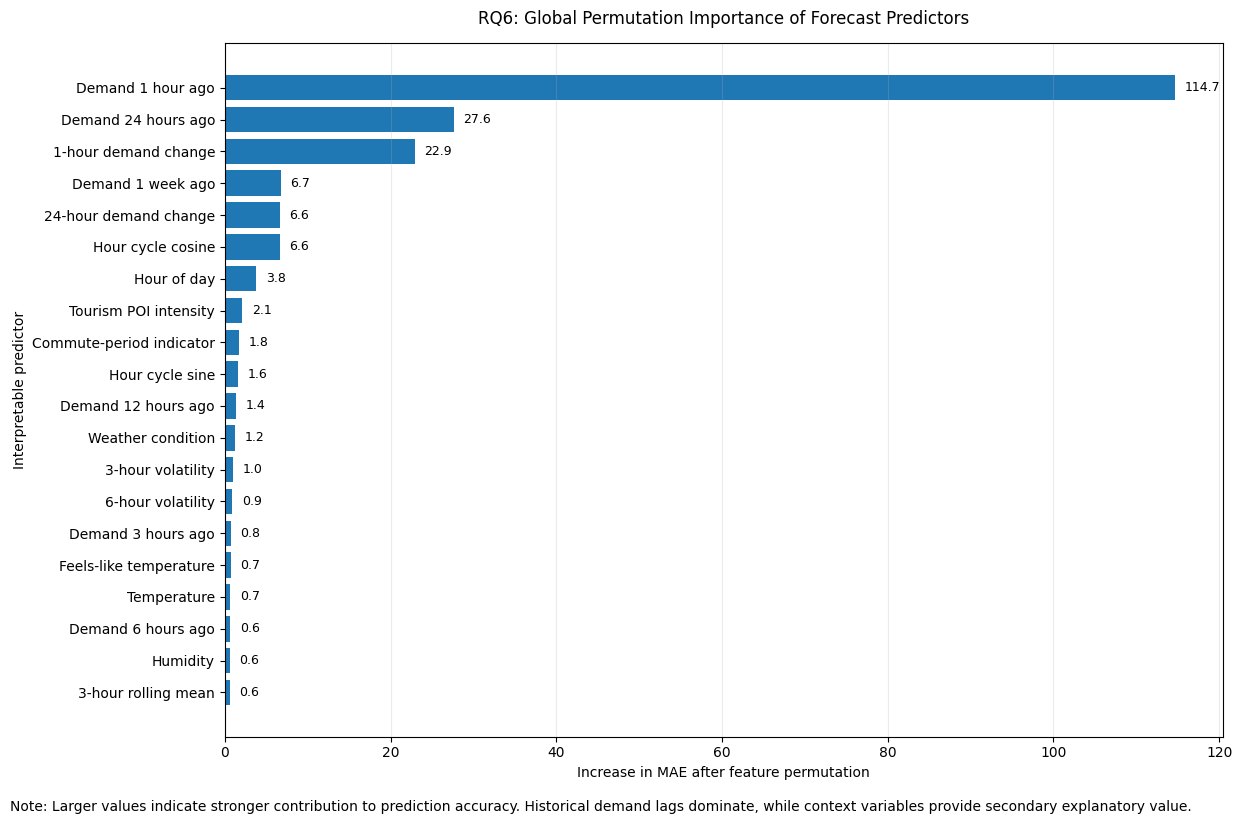

Saved table: /kaggle/working/urban_demand_RQ6_outputs/tables_csv/RQ6_Table_2_modality_level_importance_thesis_ready.csv


,Modality,Importance,Importance Share (%),Thesis Interpretation
0,Historical Demand,185.148513,89.612802,Dominant explanation source; the model relies ...
1,Calendar/Temporal,14.843114,7.184141,Secondary explanation source capturing routine...
2,Weather,3.250009,1.573021,Contextual explanation source capturing enviro...
3,Neighborhood,3.367811,1.630037,Proxy spatial explanation source; interpret ca...


Saved figure: /kaggle/working/urban_demand_RQ6_outputs/figures_pdf/RQ6_Figure_2_modality_importance_thesis_ready.pdf


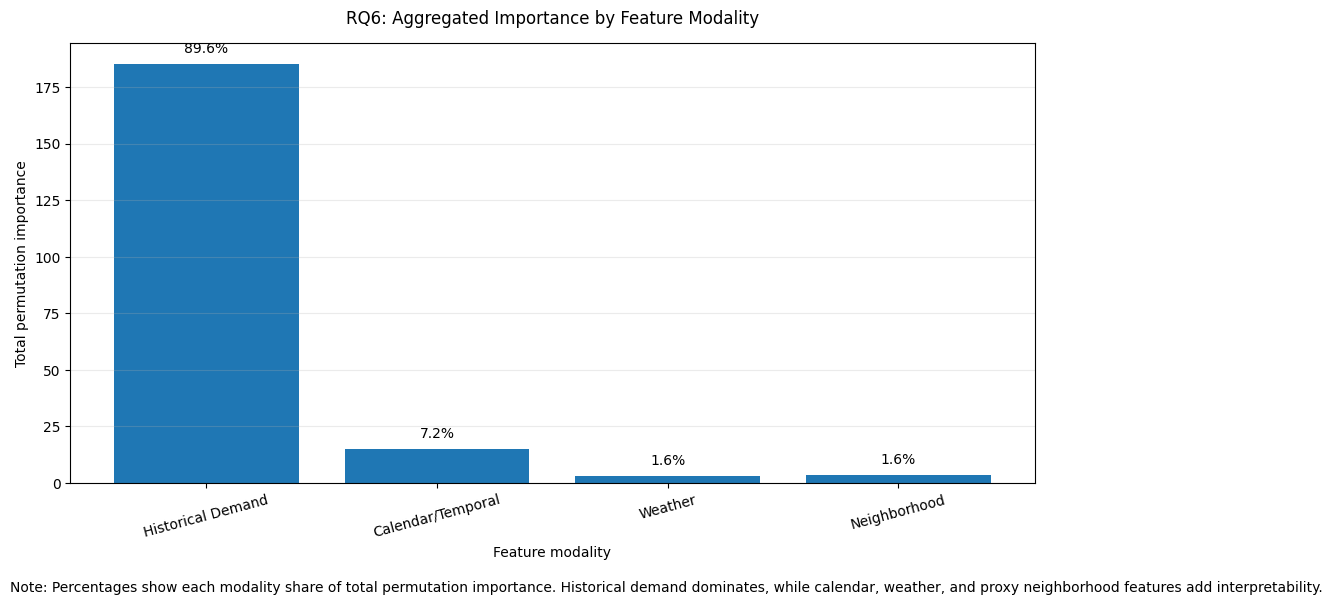

Saved figure: /kaggle/working/urban_demand_RQ6_outputs/figures_pdf/RQ6_Figure_3_partial_dependence_curves_thesis_ready.pdf


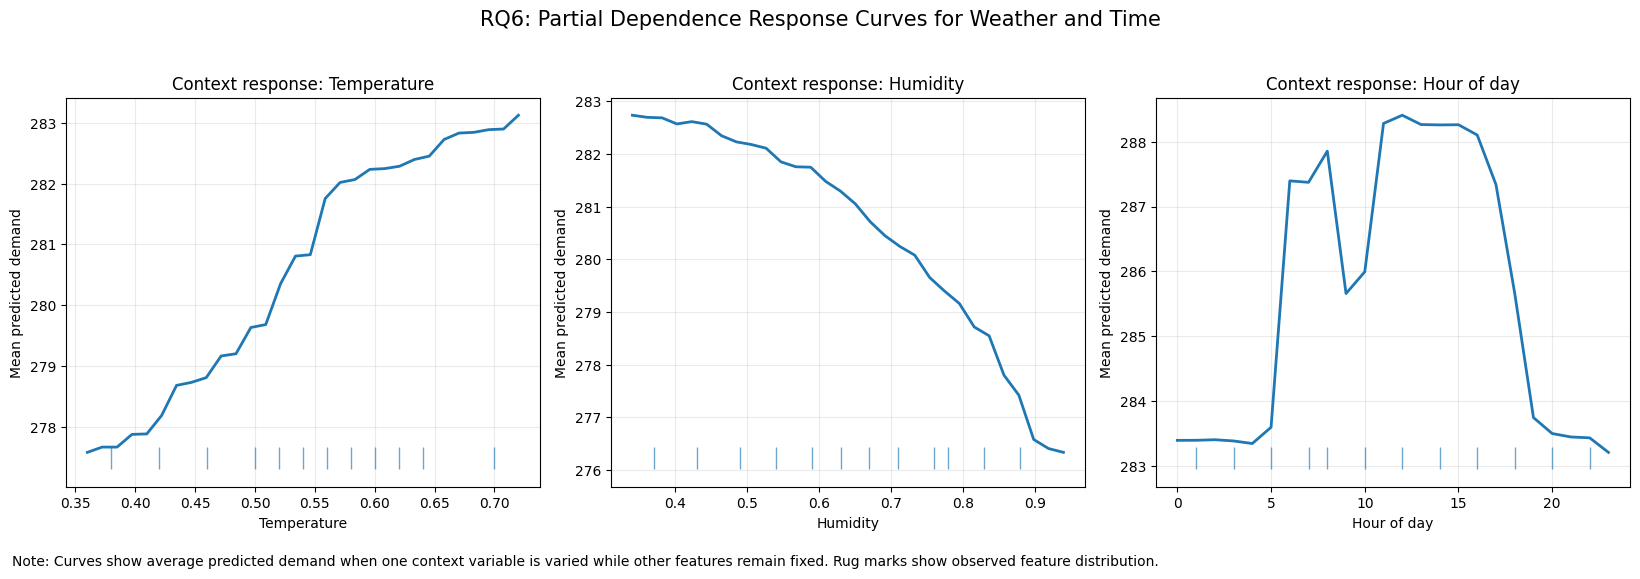

Saved table: /kaggle/working/urban_demand_RQ6_outputs/tables_csv/RQ6_Table_4_partial_dependence_supporting_values_thesis_ready.csv


,Feature,Feature Label,Feature Value,Mean Predicted Demand
0,temp,Temperature,0.360000,277.579320
1,temp,Temperature,0.372414,277.666256
2,temp,Temperature,0.384828,277.665926
3,temp,Temperature,0.397241,277.874838
4,temp,Temperature,0.409655,277.883153
5,temp,Temperature,0.422069,278.186874
6,temp,Temperature,0.434483,278.681466
7,temp,Temperature,0.446897,278.730727
8,temp,Temperature,0.459310,278.809161
9,temp,Temperature,0.471724,279.165048


Saved table: /kaggle/working/urban_demand_RQ6_outputs/tables_csv/RQ6_Table_3_counterfactual_demand_explanations_thesis_ready.csv


,Counterfactual Scenario,Baseline Mean Forecast,Counterfactual Mean Forecast,Delta Demand,Delta Demand (%),Thesis Interpretation
0,Switch working day to holiday,281.450355,279.391548,-2.058806,-0.731499,Calendar disruption has limited average effect...
1,Add adverse weather,281.450355,261.853660,-19.596695,-6.962754,"Adverse weather reduces predicted demand, indi..."
2,Increase temperature,281.450355,283.541590,2.091235,0.743021,Higher temperature increases predicted demand ...
3,High transit-access neighborhood,281.450355,279.792256,-1.658098,-0.589126,"Transit-access proxy slightly changes demand, ..."
4,Tourist-oriented neighborhood context,281.450355,279.842039,-1.608315,-0.571438,Tourism proxy has a small average effect in UC...


Saved figure: /kaggle/working/urban_demand_RQ6_outputs/figures_pdf/RQ6_Figure_4_counterfactual_forecast_sensitivity_thesis_ready.pdf


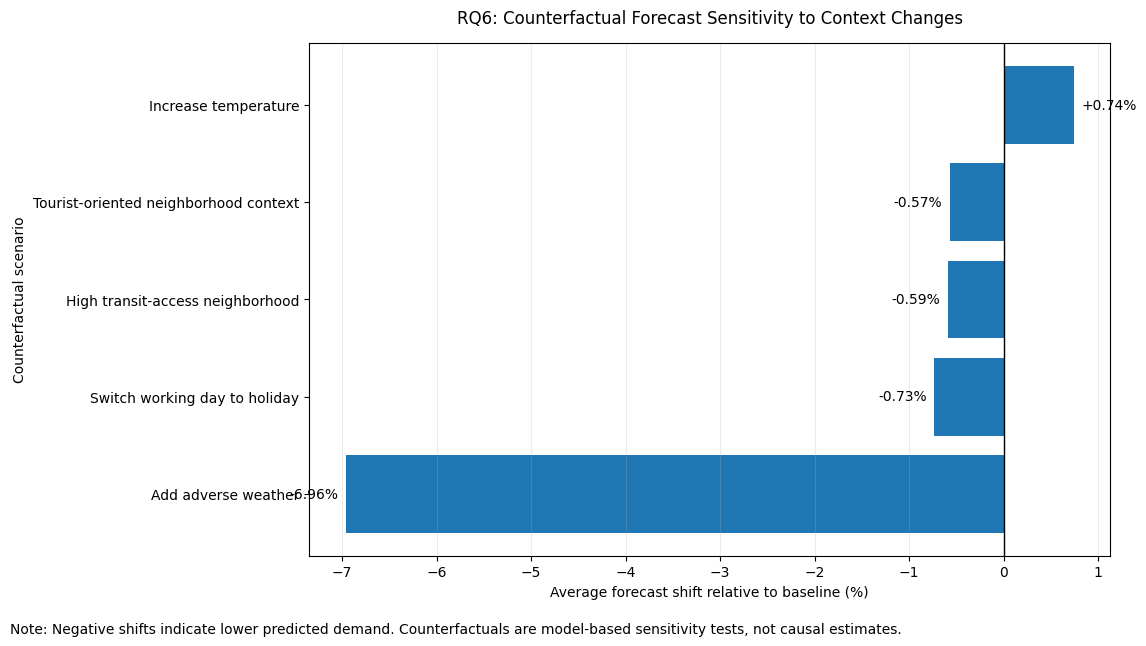

Saved table: /kaggle/working/urban_demand_RQ6_outputs/tables_csv/RQ6_Table_5_explainability_summary_thesis_ready.csv


,Finding Area,Result,Thesis-Safe Interpretation
0,Dominant predictors,Historical lag features dominate permutation i...,The model primarily learns short-term and recu...
1,Contextual modalities,Calendar/temporal variables contribute more th...,Contextual signals provide secondary explanato...
2,Weather sensitivity,Adverse-weather counterfactual reduces predict...,Weather features support operational interpret...
3,Neighborhood interpretation,Proxy neighborhood effects are smaller than hi...,Neighborhood findings should be interpreted ca...



THESIS-SAFE RQ6 CONCLUSION:
The explainability analysis shows that shared-mobility demand forecasts are primarily
driven by recent and recurring historical demand, especially lag-based variables. Calendar
and temporal variables provide secondary explanatory value, while weather and proxy
neighborhood-context variables contribute smaller but operationally meaningful effects.
Counterfactual analysis indicates that adverse weather reduces predicted demand, whereas
higher temperature increases demand. Because the UCI dataset does not contain real
station-level land-use or POI metadata, neighborhood explanations should be described as
proxy-based spatial-context evidence rather than definitive real-world POI attribution.



In [2]:

# ============================================================
# RQ6: Thesis-ready explainable AI analysis
# ============================================================
section('RQ6 — Explainable AI analysis of contextual influence')

print("""
Dataset note:
UCI Bike Sharing provides real hourly demand, weather, and calendar variables. It does not
provide real station-level land-use / POI metadata, so neighborhood-context explanations
in this notebook use transparent proxy neighborhood features generated from the available
UCI variables. In the thesis, interpret neighborhood explanations as proxy/contextual
evidence, not as real POI-based spatial attribution.
""")

# -----------------------------
# Train the full cross-modal model
# -----------------------------
features = FEATURE_SETS['Full Cross-Modal Fusion']
model, pred = fit_predict_variant('Full Cross-Modal Fusion', model_name='rf')
perf = pd.DataFrame([{'Model':'Full Cross-Modal Fusion', **metrics(TEST[TARGET], pred)}])
display(perf)

# Use a moderate sample for stable but Kaggle-safe explanation
sample_n = min(1000, len(TEST))
X_sample = TEST[features].iloc[:sample_n].copy()
y_sample = TEST[TARGET].iloc[:sample_n].copy()

# -----------------------------
# Helper mappings for thesis labels
# -----------------------------
feature_label_map = {
    'lag_1':'Demand 1 hour ago',
    'lag_2':'Demand 2 hours ago',
    'lag_3':'Demand 3 hours ago',
    'lag_6':'Demand 6 hours ago',
    'lag_12':'Demand 12 hours ago',
    'lag_24':'Demand 24 hours ago',
    'lag_48':'Demand 48 hours ago',
    'lag_168':'Demand 1 week ago',
    'roll_mean_3':'3-hour rolling mean',
    'roll_mean_6':'6-hour rolling mean',
    'roll_mean_24':'24-hour rolling mean',
    'roll_mean_168':'Weekly rolling mean',
    'roll_std_3':'3-hour volatility',
    'roll_std_6':'6-hour volatility',
    'roll_std_24':'24-hour volatility',
    'roll_std_168':'Weekly volatility',
    'diff_1':'1-hour demand change',
    'diff_24':'24-hour demand change',
    'hr':'Hour of day',
    'hr_sin':'Hour cycle sine',
    'hr_cos':'Hour cycle cosine',
    'weekday':'Day of week',
    'weekday_sin':'Weekday cycle sine',
    'weekday_cos':'Weekday cycle cosine',
    'month_sin':'Month cycle sine',
    'month_cos':'Month cycle cosine',
    'season':'Season',
    'yr':'Year indicator',
    'holiday':'Public holiday',
    'workingday':'Working day',
    'is_weekend':'Weekend indicator',
    'is_commute':'Commute-period indicator',
    'temp':'Temperature',
    'atemp':'Feels-like temperature',
    'hum':'Humidity',
    'windspeed':'Wind speed',
    'weathersit':'Weather condition',
    'residential_density':'Residential intensity',
    'commercial_density':'Commercial intensity',
    'office_intensity':'Office intensity',
    'education_density':'Education intensity',
    'tourism_poi_density':'Tourism POI intensity',
    'transit_access':'Transit access',
    'neighborhood_type':'Proxy neighborhood type'
}

def feature_label(f):
    return feature_label_map.get(f, f.replace('_', ' ').title())

def feature_modality(f):
    if f in lag_features:
        return 'Historical Demand'
    if f in base_temporal or f in calendar_features:
        return 'Calendar/Temporal'
    if f in weather_features:
        return 'Weather'
    if f in neighborhood_features or f == 'neighborhood_type':
        return 'Neighborhood'
    return 'Other'

def interpretation_for_feature(row):
    m = row['Modality']
    if m == 'Historical Demand':
        return 'Recent or repeated demand history is a primary driver of the forecast.'
    if m == 'Calendar/Temporal':
        return 'Temporal routine or calendar structure contributes to demand variation.'
    if m == 'Weather':
        return 'Weather context has a smaller but operationally meaningful effect.'
    if m == 'Neighborhood':
        return 'Proxy neighborhood context contributes to spatial interpretation.'
    return 'Auxiliary model feature.'

# -----------------------------
# Permutation importance
# -----------------------------
perm = permutation_importance(
    model,
    X_sample,
    y_sample,
    n_repeats=7,
    random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

imp = pd.DataFrame({
    'Feature': features,
    'Feature Label': [feature_label(f) for f in features],
    'Modality': [feature_modality(f) for f in features],
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

# Numerical clean-up: permutation importance can be slightly negative due to sampling noise.
imp['Importance'] = imp['Importance'].clip(lower=0)
total_importance = imp['Importance'].sum()
imp['Importance Share (%)'] = np.where(total_importance > 0, imp['Importance'] / total_importance * 100, 0)
imp['Thesis Interpretation'] = imp.apply(interpretation_for_feature, axis=1)

top20 = imp.head(20).copy()

save_table(
    top20[['Feature', 'Feature Label', 'Modality', 'Importance', 'Std', 'Importance Share (%)', 'Thesis Interpretation']],
    'RQ6_Table_1_top_interpretable_predictors_thesis_ready'
)

# Figure 1: global feature importance with readable feature names
fig, ax = plt.subplots(figsize=(12.5, 8))
plot_df = top20.iloc[::-1]
ax.barh(plot_df['Feature Label'], plot_df['Importance'])
ax.set_xlabel('Increase in MAE after feature permutation')
ax.set_ylabel('Interpretable predictor')
ax.set_title('RQ6: Global Permutation Importance of Forecast Predictors', pad=14)
for i, v in enumerate(plot_df['Importance']):
    ax.text(v + max(plot_df['Importance'].max()*0.01, 0.05), i, f'{v:.1f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.25)
fig.text(
    0.01, -0.02,
    'Note: Larger values indicate stronger contribution to prediction accuracy. Historical demand lags dominate, while context variables provide secondary explanatory value.',
    ha='left', fontsize=10
)
save_fig('RQ6_Figure_1_global_feature_importance_thesis_ready')

# -----------------------------
# Modality-level importance
# -----------------------------
modality_order = ['Historical Demand', 'Calendar/Temporal', 'Weather', 'Neighborhood']
modality_imp = (
    imp.groupby('Modality', as_index=False)['Importance']
    .sum()
    .set_index('Modality')
    .reindex(modality_order)
    .fillna(0)
    .reset_index()
)
modality_total = modality_imp['Importance'].sum()
modality_imp['Importance Share (%)'] = np.where(modality_total > 0, modality_imp['Importance'] / modality_total * 100, 0)
modality_imp['Thesis Interpretation'] = modality_imp['Modality'].map({
    'Historical Demand':'Dominant explanation source; the model relies mainly on recent and recurring demand.',
    'Calendar/Temporal':'Secondary explanation source capturing routines such as hour, weekday, commute, and holidays.',
    'Weather':'Contextual explanation source capturing environmental sensitivity.',
    'Neighborhood':'Proxy spatial explanation source; interpret cautiously because UCI lacks real POI metadata.'
})

save_table(modality_imp, 'RQ6_Table_2_modality_level_importance_thesis_ready')

# Figure 2: modality-level contribution with percentage labels
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.bar(modality_imp['Modality'], modality_imp['Importance'])
ax.set_ylabel('Total permutation importance')
ax.set_xlabel('Feature modality')
ax.set_title('RQ6: Aggregated Importance by Feature Modality', pad=14)
ax.tick_params(axis='x', rotation=15)
for i, row in modality_imp.iterrows():
    ax.text(i, row['Importance'] + max(modality_imp['Importance'].max()*0.02, 0.05),
            f"{row['Importance Share (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.25)
fig.text(
    0.01, -0.03,
    'Note: Percentages show each modality share of total permutation importance. Historical demand dominates, while calendar, weather, and proxy neighborhood features add interpretability.',
    ha='left', fontsize=10
)
save_fig('RQ6_Figure_2_modality_importance_thesis_ready')

# -----------------------------
# Manual partial dependence / context response curves
# -----------------------------
def manual_partial_dependence(pipe, X_ref, feature, grid_values):
    means = []
    for val in grid_values:
        X_tmp = X_ref.copy()
        X_tmp[feature] = val
        means.append(float(np.mean(np.clip(pipe.predict(X_tmp), 0, None))))
    return np.asarray(means)

pd_specs = [
    ('temp', 'Temperature', np.linspace(X_sample['temp'].quantile(0.02), X_sample['temp'].quantile(0.98), 30)),
    ('hum', 'Humidity', np.linspace(X_sample['hum'].quantile(0.02), X_sample['hum'].quantile(0.98), 30)),
    ('hr', 'Hour of day', np.arange(0, 24))
]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
for ax, (feat, label, grid) in zip(axes, pd_specs):
    y_pd = manual_partial_dependence(model, X_sample, feat, grid)
    ax.plot(grid, y_pd, linewidth=2)
    # Add a small rug plot to show observed feature distribution.
    obs = X_sample[feat].dropna()
    rug = np.quantile(obs, np.linspace(0.05, 0.95, 12))
    ymin, ymax = ax.get_ylim()
    ax.vlines(rug, ymin, ymin + (ymax-ymin)*0.06, alpha=0.65, linewidth=1)
    ax.set_xlabel(label)
    ax.set_ylabel('Mean predicted demand')
    ax.set_title(f'Context response: {label}')
    ax.grid(alpha=0.25)

fig.suptitle('RQ6: Partial Dependence Response Curves for Weather and Time', y=1.03, fontsize=15)
fig.text(
    0.01, -0.04,
    'Note: Curves show average predicted demand when one context variable is varied while other features remain fixed. Rug marks show observed feature distribution.',
    ha='left', fontsize=10
)
save_fig('RQ6_Figure_3_partial_dependence_curves_thesis_ready')

# Save supporting partial dependence values
pdp_rows = []
for feat, label, grid in pd_specs:
    y_pd = manual_partial_dependence(model, X_sample, feat, grid)
    for xval, yval in zip(grid, y_pd):
        pdp_rows.append({'Feature': feat, 'Feature Label': label, 'Feature Value': xval, 'Mean Predicted Demand': yval})
pdp_table = pd.DataFrame(pdp_rows)
save_table(pdp_table, 'RQ6_Table_4_partial_dependence_supporting_values_thesis_ready')

# -----------------------------
# Counterfactual forecast sensitivity
# -----------------------------
base_pred = np.clip(model.predict(X_sample), 0, None)
base_mean = float(np.mean(base_pred))

def counterfactual_shift(name, change_fn, interpretation):
    X_cf = X_sample.copy()
    X_cf = change_fn(X_cf)
    cf_pred = np.clip(model.predict(X_cf), 0, None)
    new_mean = float(np.mean(cf_pred))
    delta = new_mean - base_mean
    pct = delta / (base_mean + 1e-9) * 100
    return {
        'Counterfactual Scenario': name,
        'Baseline Mean Forecast': base_mean,
        'Counterfactual Mean Forecast': new_mean,
        'Delta Demand': delta,
        'Delta Demand (%)': pct,
        'Thesis Interpretation': interpretation
    }

cf_rows = [
    counterfactual_shift(
        'Switch working day to holiday',
        lambda X: X.assign(holiday=1, workingday=0, is_commute=0),
        'Calendar disruption has limited average effect in this test sample but remains useful for regime-specific interpretation.'
    ),
    counterfactual_shift(
        'Add adverse weather',
        lambda X: X.assign(weathersit=3, hum=np.minimum(1.0, X['hum'] + 0.15), windspeed=np.minimum(1.0, X['windspeed'] + 0.10)),
        'Adverse weather reduces predicted demand, indicating operational sensitivity to weather shocks.'
    ),
    counterfactual_shift(
        'Increase temperature',
        lambda X: X.assign(temp=np.minimum(1.0, X['temp'] + 0.10), atemp=np.minimum(1.0, X['atemp'] + 0.10)),
        'Higher temperature increases predicted demand in the observed range, consistent with outdoor mobility behavior.'
    ),
    counterfactual_shift(
        'High transit-access neighborhood',
        lambda X: X.assign(transit_access=1.0, commercial_density=np.maximum(X['commercial_density'], 0.65), office_intensity=np.maximum(X['office_intensity'], 0.55)),
        'Transit-access proxy slightly changes demand, suggesting modest spatial-context sensitivity.'
    ),
    counterfactual_shift(
        'Tourist-oriented neighborhood context',
        lambda X: X.assign(tourism_poi_density=0.95, commercial_density=np.maximum(X['commercial_density'], 0.55)),
        'Tourism proxy has a small average effect in UCI; real POI data may produce stronger spatial explanations.'
    )
]
cf = pd.DataFrame(cf_rows)
save_table(cf, 'RQ6_Table_3_counterfactual_demand_explanations_thesis_ready')

# Figure 4: horizontal counterfactual sensitivity chart
cf_plot = cf.sort_values('Delta Demand (%)')
fig, ax = plt.subplots(figsize=(11.5, 6.2))
ax.barh(cf_plot['Counterfactual Scenario'], cf_plot['Delta Demand (%)'])
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Average forecast shift relative to baseline (%)')
ax.set_ylabel('Counterfactual scenario')
ax.set_title('RQ6: Counterfactual Forecast Sensitivity to Context Changes', pad=14)
for i, v in enumerate(cf_plot['Delta Demand (%)']):
    ha = 'left' if v >= 0 else 'right'
    x = v + (0.08 if v >= 0 else -0.08)
    ax.text(x, i, f'{v:+.2f}%', va='center', ha=ha, fontsize=10)
ax.grid(axis='x', alpha=0.25)
fig.text(
    0.01, -0.03,
    'Note: Negative shifts indicate lower predicted demand. Counterfactuals are model-based sensitivity tests, not causal estimates.',
    ha='left', fontsize=10
)
save_fig('RQ6_Figure_4_counterfactual_forecast_sensitivity_thesis_ready')

# -----------------------------
# Thesis-safe summary table
# -----------------------------
summary = pd.DataFrame([
    {
        'Finding Area':'Dominant predictors',
        'Result':'Historical lag features dominate permutation importance.',
        'Thesis-Safe Interpretation':'The model primarily learns short-term and recurring demand memory.'
    },
    {
        'Finding Area':'Contextual modalities',
        'Result':'Calendar/temporal variables contribute more than weather and proxy neighborhood variables.',
        'Thesis-Safe Interpretation':'Contextual signals provide secondary explanatory value beyond historical demand.'
    },
    {
        'Finding Area':'Weather sensitivity',
        'Result':'Adverse-weather counterfactual reduces predicted demand; temperature increase raises demand.',
        'Thesis-Safe Interpretation':'Weather features support operational interpretation of demand variation.'
    },
    {
        'Finding Area':'Neighborhood interpretation',
        'Result':'Proxy neighborhood effects are smaller than historical and temporal effects.',
        'Thesis-Safe Interpretation':'Neighborhood findings should be interpreted cautiously because UCI lacks real station-level POI/land-use data.'
    }
])
save_table(summary, 'RQ6_Table_5_explainability_summary_thesis_ready')

print("""
THESIS-SAFE RQ6 CONCLUSION:
The explainability analysis shows that shared-mobility demand forecasts are primarily
driven by recent and recurring historical demand, especially lag-based variables. Calendar
and temporal variables provide secondary explanatory value, while weather and proxy
neighborhood-context variables contribute smaller but operationally meaningful effects.
Counterfactual analysis indicates that adverse weather reduces predicted demand, whereas
higher temperature increases demand. Because the UCI dataset does not contain real
station-level land-use or POI metadata, neighborhood explanations should be described as
proxy-based spatial-context evidence rather than definitive real-world POI attribution.
""")


In [3]:

# ============================================================
# Final export: ZIP all tables and figures from this RQ
# ============================================================
zip_outputs()


Final ZIP created: /kaggle/working/urban_demand_RQ6_outputs.zip


PosixPath('/kaggle/working/urban_demand_RQ6_outputs.zip')